<a href="https://colab.research.google.com/github/vanshey0009/Naive_bayes/blob/main/project_UsingNaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# PROJECT : TEXT ANALYTICS FOR SPAM DETECTION USING NAIVE BAYES

In [2]:
import pandas as pd # pandas is use for load data , create features , clean data , etc.
import numpy as np # numerical python is use for faster numerical computation
df=pd.read_csv('/content/train.csv')
print(df.head())

                                                 sms  label
0  Go until jurong point, crazy.. Available only ...      0
1                    Ok lar... Joking wif u oni...\n      0
2  Free entry in 2 a wkly comp to win FA Cup fina...      1
3  U dun say so early hor... U c already then say...      0
4  Nah I don't think he goes to usf, he lives aro...      0


In [3]:
message = 'sms'
target = 'label'
X = df[message]
y = df[target]

print(df.shape)
print(df.info)

(5574, 2)
<bound method DataFrame.info of                                                     sms  label
0     Go until jurong point, crazy.. Available only ...      0
1                       Ok lar... Joking wif u oni...\n      0
2     Free entry in 2 a wkly comp to win FA Cup fina...      1
3     U dun say so early hor... U c already then say...      0
4     Nah I don't think he goes to usf, he lives aro...      0
...                                                 ...    ...
5569  This is the 2nd time we have tried 2 contact u...      1
5570             Will ü b going to esplanade fr home?\n      0
5571  Pity, * was in mood for that. So...any other s...      0
5572  The guy did some bitching but I acted like i'd...      0
5573                       Rofl. Its true to its name\n      0

[5574 rows x 2 columns]>


In [4]:
from sklearn.model_selection import train_test_split  # it is used spilt a data in training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(

    X, y, test_size=0.2,
    random_state=42
    )

In [5]:
from sklearn.feature_extraction.text import CountVectorizer # it convert text data into numerical data

vectorizer = CountVectorizer(stop_words='english')
X_train_counts = vectorizer.fit_transform(X_train)

X_test_counts = vectorizer.transform(X_test)


In [6]:
from sklearn.naive_bayes import MultinomialNB
# Multinomial Naive Bayes is a classification algorithm commonly used for text classification tasks

clf = MultinomialNB()
clf.fit(X_train_counts, y_train)


y_pred = clf.predict(X_test_counts)
clf = MultinomialNB()
clf.fit(X_train_counts, y_train)


from sklearn.metrics import accuracy_score, classification_report
# Accuracy= Total Predictions / Number of Correct Predictions.

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9847533632286996

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       954
           1       0.96      0.93      0.95       161

    accuracy                           0.98      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.98      0.98      0.98      1115



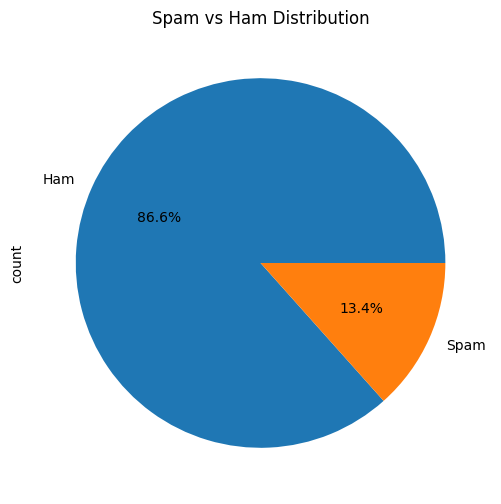

In [7]:
import matplotlib.pyplot as plt
# used for data visualization and plotting graphs, charts.
plt.figure(figsize=(6,6))

df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Ham','Spam']
)

plt.title("Spam vs Ham Distribution")
plt.show()

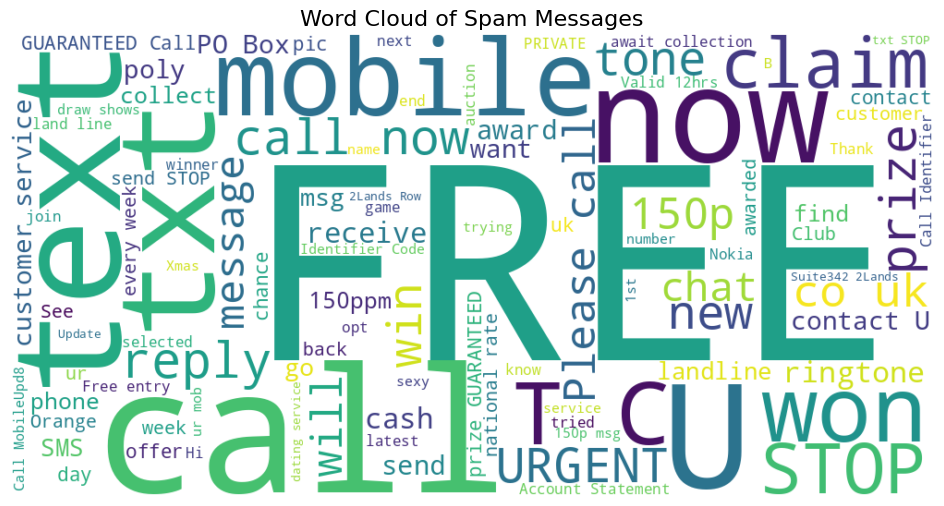

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all spam messages into one text
spam_text = " ".join(df[df['label'] == 1]['sms'])

# Generate Word Cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    max_words=100
).generate(spam_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Spam Messages", fontsize=16)
plt.show()

In [9]:
import pandas as pd

# Create error analysis dataframe
error_df = pd.DataFrame({
    'Message': X_test,
    'Actual Label': y_test,
    'Predicted Label': y_pred
})

# Keep only incorrect predictions
errors = error_df[error_df['Actual Label'] != error_df['Predicted Label']]

# Replace labels with names
errors['Actual Label'] = errors['Actual Label'].map({0:'Ham', 1:'Spam'})
errors['Predicted Label'] = errors['Predicted Label'].map({0:'Ham', 1:'Spam'})

print("Number of Misclassified Messages:", len(errors))
errors.head(20)

Number of Misclassified Messages: 17


/tmp/ipykernel_1618/3383465537.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors['Actual Label'] = errors['Actual Label'].map({0:'Ham', 1:'Spam'})
/tmp/ipykernel_1618/3383465537.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors['Predicted Label'] = errors['Predicted Label'].map({0:'Ham', 1:'Spam'})


,Message,Actual Label,Predicted Label
3742,2/2 146tf150p\n,Spam,Ham
4600,Have you laid your airtel line to rest?\n,Ham,Spam
1893,CALL 09090900040 & LISTEN TO EXTREME DIRTY LIV...,Spam,Ham
4419,"When you get free, call me\n",Ham,Spam
2663,Hello darling how are you today? I would love ...,Spam,Ham
4821,Check Out Choose Your Babe Videos @ sms.shsex....,Spam,Ham
751,"Do you realize that in about 40 years, we'll h...",Spam,Ham
4702,I liked the new mobile\n,Ham,Spam
3864,Oh my god! I've found your number again! I'm s...,Spam,Ham
5046,We have sent JD for Customer Service cum Accou...,Ham,Spam


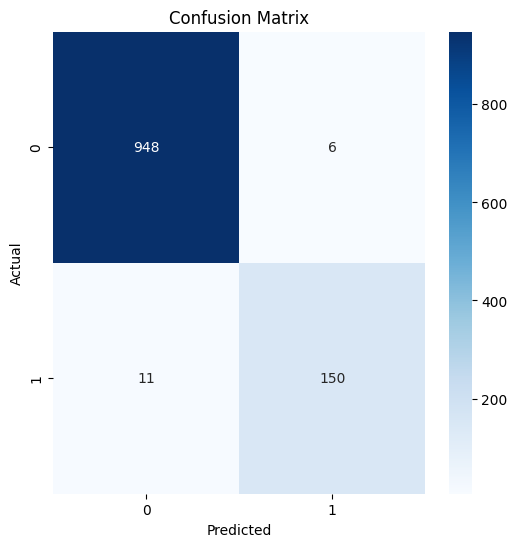

In [10]:
from sklearn.metrics import confusion_matrix
# it is use for comparing the actual values with the predicted values.
import matplotlib.pyplot as plt
import seaborn as sns # It is used to create attractive and informative statistical graphs with less code.

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

/tmp/ipykernel_1618/1589550033.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='spam indicator', y='word', data=top_spam_words, palette='deep')


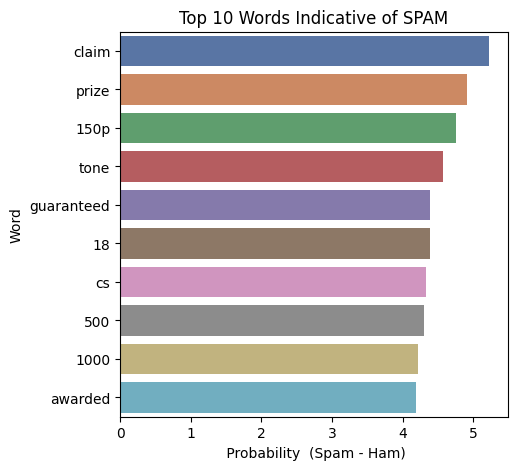

/tmp/ipykernel_1618/1589550033.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='spam indicator', y='word', data=top_ham_words, palette='deep')


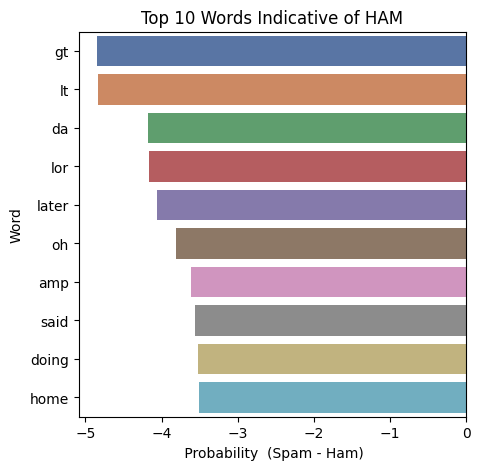

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

feature_names = vectorizer.get_feature_names_out()
log_probs_ham = clf.feature_log_prob_[0]
log_probs_spam = clf.feature_log_prob_[1]


words = pd.DataFrame({
    'word': feature_names,
    'ham sms': log_probs_ham,
    'spam sms': log_probs_spam
})


words['spam indicator'] = words['spam sms'] - words['ham sms']


top_spam_words = words.sort_values(by='spam indicator', ascending=False).head(10)

top_ham_words = words.sort_values(by='spam indicator', ascending=True).head(10)


plt.figure(figsize=(5, 5))
sns.barplot(x='spam indicator', y='word', data=top_spam_words, palette='deep')
plt.title('Top 10 Words Indicative of SPAM')
plt.xlabel(' Probability  (Spam - Ham)')
plt.ylabel('Word')
plt.show()


plt.figure(figsize=(5, 5))
sns.barplot(x='spam indicator', y='word', data=top_ham_words, palette='deep')
plt.title('Top 10 Words Indicative of HAM')
plt.xlabel(' Probability  (Spam - Ham)')
plt.ylabel('Word')
plt.show()

### Message Length Analysis

Let's analyze the length of the messages to see if there's a difference between spam and ham messages.

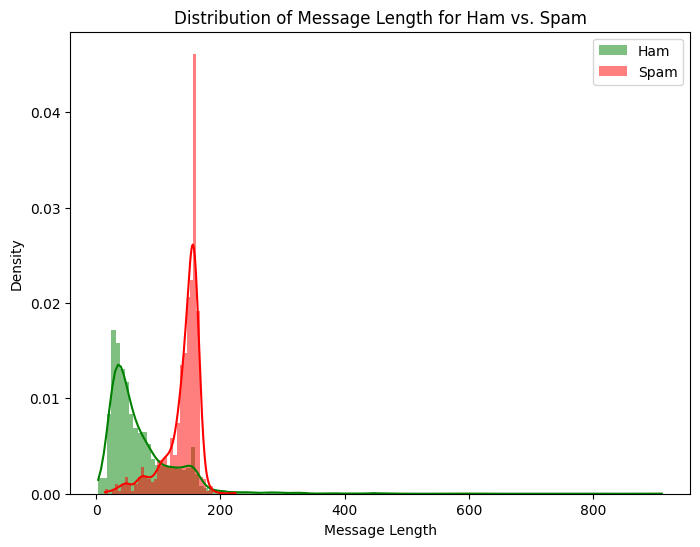

In [12]:
df['message_length'] = df['sms'].apply(len)

plt.figure(figsize=(8, 6))
sns.histplot(df[df['label']==0]['message_length'], color='green', label='Ham', kde=True, stat='density', linewidth=0)
sns.histplot(df[df['label']==1]['message_length'], color='red', label='Spam', kde=True, stat='density', linewidth=0)
plt.title('Distribution of Message Length for Ham vs. Spam')
plt.xlabel('Message Length')
plt.ylabel('Density')
plt.legend()
plt.show()

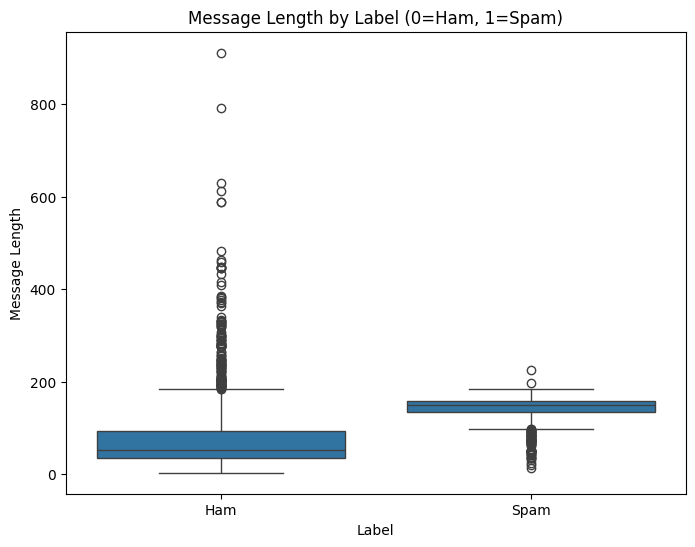

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='label', y='message_length', data=df)
plt.title('Message Length by Label (0=Ham, 1=Spam)')
plt.xlabel('Label')
plt.ylabel('Message Length')
plt.xticks(ticks=[0, 1], labels=['Ham', 'Spam'])
plt.show()

In [14]:
from IPython.display import HTML, display
import time

# Enter Message Screen
display(HTML("""
<div style="
width:80%;
margin:auto;
padding:30px;
text-align:center;
background:linear-gradient(135deg,#4facfe,#00f2fe);
color:white;
border-radius:20px;
font-family:Arial;
">

<h1>📧 SMS Spam Detection System</h1>

<h3>Machine Learning Based Text Analytics</h3>
<div style="
background:white;
color:black;
padding:15px;
border-radius:15px;
">

📌 Instructions

<br><br>

📩 Enter your SMS below<br>
🚪 Type <b>exit</b> to quit<br>
🔒 Never share sensitive information online

</div>

<br>



</div>



"""))

sms = input("📩 Enter Message : ")

# Processing Screen
display(HTML("""
<div style="
width:60%;
margin:auto;
padding:20px;
text-align:center;
background:#f8f9fa;
border-radius:15px;
">

<h2>🤖 Processing Message...</h2>

<p>Converting text into numerical features</p>

</div>
"""))

time.sleep(1)

# Prediction
input_label = vectorizer.transform([sms])

display(HTML("""
<div style="
width:60%;
margin:auto;
padding:20px;
text-align:center;
background:#f8f9fa;
border-radius:15px;
">


"""))

time.sleep(1)

prediction = clf.predict(input_label)[0]

# Result

if len(sms.split()) < 2:

    result = "⚠ MESSAGE TOO SHORT"
    color = "#fd7e14"

    info = """
    <h3>⚠ Short Message Warning</h3>

    Please enter a longer message for accurate prediction.<br>

    ✔ Minimum 2-3 words recommended<br>
    ✔ More text improves prediction accuracy<br>
    ✔ Try entering a complete sentence
    """

else:

    prediction = clf.predict(input_label)[0]

    if prediction == 0:

        result = "✅ HAM MESSAGE"
        color = "green"

        info = """
        <h3>🌟 Advantages</h3>

        ✔ Your text appears safe<br>
        ✔ Trusted Sender Content<br>
        ✔ No Suspicious Links Detected<br>
        ✔ Low Security Risk<br>
        ✔ Safe for Communication
        """

    else:

        result = "🚨 SPAM MESSAGE"
        color = "red"

        info = """
        <h3>🛡 Security Precautions</h3>

        ⚠ Do Not Click Unknown Links<br>
        ⚠ Never Share OTP<br>
        ⚠ Never Share Passwords<br>
        ⚠ Verify Sender Identity<br>
        ⚠ Report Suspicious Messages
        """


display(HTML(f"""
<div style="
width:80%;
margin:auto;
padding:30px;
border-radius:20px;
border:4px solid {color};
font-family:Arial;
">

<h1 style="color:{color};text-align:center;">
{result}
</h1>

<hr>

<h3>📨 Message</h3>

<p>{sms}</p>

<h3>📋 THER ARE SOME THINGS WHICH YOU KNOW ABOUT TEXT </h3>



{info}


"""))

📩 Enter Message : you have to claim your price


## Create a Python script for the spam detection model

To make the spam detection model runnable within a Docker container, we'll extract the core logic into a Python script (`spam_detector.py`). This script will take a message as a command-line argument and output whether it's spam or ham.

In [15]:
%%writefile spam_detector.py

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
import sys

# Load the dataset (assuming train.csv is in the same directory)
df = pd.read_csv('train.csv')

# Prepare data
message = 'sms'
target = 'label'
X = df[message]
y = df[target]

# Split data (necessary for fitting the vectorizer and classifier)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Vectorize text
vectorizer = CountVectorizer(stop_words='english')
X_train_counts = vectorizer.fit_transform(X_train)

# Train the Naive Bayes Classifier
clf = MultinomialNB()
clf.fit(X_train_counts, y_train)

def predict_spam_or_ham(sms_message):
    if not sms_message.strip():
        return "Please enter a message."

    # Transform the input message
    input_counts = vectorizer.transform([sms_message])

    # Predict
    prediction = clf.predict(input_counts)[0]

    if prediction == 0:
        return "HAM MESSAGE"
    else:
        return "SPAM MESSAGE"

if __name__ == "__main__":
    if len(sys.argv) > 1:
        input_message = " ".join(sys.argv[1:])
        print(predict_spam_or_ham(input_message))
    else:
        print("Usage: python spam_detector.py \"Your message here\"")


Writing spam_detector.py


## Create the Dockerfile

Now, let's create the `Dockerfile` to build an image for this script. Make sure `train.csv` is in the same directory as your `Dockerfile` and `spam_detector.py`.

In [16]:
%%writefile Dockerfile

# Use an official Python runtime as a parent image
FROM python:3.9-slim-buster

# Set the working directory in the container
WORKDIR /app

# Copy the current directory contents into the container at /app
COPY . /app

# Install any needed packages specified in requirements.txt
# (We'll create a requirements.txt next)
RUN pip install --no-cache-dir pandas scikit-learn

# Define environment variable
ENV PYTHONUNBUFFERED 1

# Run the spam_detector.py script
CMD ["python", "spam_detector.py"]


Writing Dockerfile


## Create `requirements.txt`

Although we already included the `pip install` command in the `Dockerfile`, it's good practice to have a `requirements.txt` file.

In [17]:
%%writefile requirements.txt
pandas
scikit-learn

Writing requirements.txt


## How to Build and Run the Docker Image

1.  **Save the files**: Make sure `train.csv`, `spam_detector.py`, `Dockerfile`, and `requirements.txt` are all in the same directory on your local machine.

2.  **Build the Docker image**: Open your terminal or command prompt, navigate to that directory, and run the following command:

    ```bash
    docker build -t spam-detector .
    ```

    This command builds a Docker image named `spam-detector` from the `Dockerfile` in the current directory.

3.  **Run the Docker container**: Once the image is built, you can run it to classify an SMS message. For example:

    ```bash
    docker run spam-detector "Free entry in 2 a wkly comp to win FA Cup final"
    ```

    Or for a ham message:

    ```bash
    docker run spam-detector "Hey, how are you doing today?"
    ```

    The container will execute the `spam_detector.py` script with your message as an argument and print the classification (HAM MESSAGE or SPAM MESSAGE) to your terminal.

## Create `app.py` for a Flask Web Application

This `app.py` file will define a simple Flask application. When the application starts, it will load the `train.csv` dataset, train the `CountVectorizer` and `MultinomialNB` model. It will then expose a `/predict` endpoint where you can send an SMS message and receive a spam/ham classification.

In [18]:
%%writefile app.py

from flask import Flask, request, jsonify
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
import os

app = Flask(__name__)

# Global variables to hold the trained vectorizer and classifier
vectorizer = None
clf = None

def train_model():
    global vectorizer, clf
    # Load the dataset (assuming train.csv is in the same directory)
    if not os.path.exists('train.csv'):
        print("Error: train.csv not found. Please ensure it's in the same directory as app.py")
        exit(1)

    df = pd.read_csv('train.csv')

    # Prepare data
    message = 'sms'
    target = 'label'
    X = df[message]
    y = df[target]

    # Split data (necessary for fitting the vectorizer and classifier)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Vectorize text
    vectorizer = CountVectorizer(stop_words='english')
    X_train_counts = vectorizer.fit_transform(X_train)

    # Train the Naive Bayes Classifier
    clf = MultinomialNB()
    clf.fit(X_train_counts, y_train)
    print("Model trained successfully.")


@app.route('/predict', methods=['POST'])
def predict_spam_or_ham_api():
    if not request.is_json:
        return jsonify({"error": "Request must be JSON"}), 400

    data = request.get_json()
    sms_message = data.get('message', '')

    if not sms_message.strip():
        return jsonify({"prediction": "Please provide a message for prediction."}), 400

    if vectorizer is None or clf is None:
        return jsonify({"error": "Model not trained yet. Please wait for initialization or check for errors."}), 500

    # Transform the input message
    input_counts = vectorizer.transform([sms_message])

    # Predict
    prediction_label = clf.predict(input_counts)[0]

    result = "HAM MESSAGE" if prediction_label == 0 else "SPAM MESSAGE"
    return jsonify({"prediction": result})


@app.route('/')
def home():
    return "SMS Spam Detection API. Use /predict endpoint with a POST request."


if __name__ == '__main__':
    # Train the model when the application starts
    train_model()
    # Run the Flask application
    app.run(host='0.0.0.0', port=5000, debug=True)


Writing app.py


## How to Run and Test `app.py`

1.  **Save the files**: Ensure `train.csv` and `app.py` are in the same directory.

2.  **Install Flask**: If you haven't already, install Flask in your environment:

    ```bash
    pip install Flask
    ```

3.  **Run the application**: Open your terminal or command prompt, navigate to the directory containing `app.py`, and run:

    ```bash
    python app.py
    ```

    The application will start, train the model, and then be accessible, typically at `http://127.0.0.1:5000/`.

4.  **Test the API endpoint**: You can test the `/predict` endpoint using `curl` or a tool like Postman.

    **Using curl (for a ham message):**

    ```bash
    curl -X POST -H "Content-Type: application/json" -d '{"message": "Hey, how are you doing today?"}' http://127.0.0.1:5000/predict
    ```

    **Using curl (for a spam message):**

    ```bash
    curl -X POST -H "Content-Type: application/json" -d '{"message": "Free entry in 2 a wkly comp to win FA Cup final"}' http://127.0.0.1:5000/predict
    ```

    The API will return a JSON response like `{"prediction": "HAM MESSAGE"}` or `{"prediction": "SPAM MESSAGE"}`.

In [19]:
!find . -name "Dockerfile"

./Dockerfile
